# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [9]:




# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt






In [11]:




# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv") #completa el código
usage = pd.read_csv("/datasets/usage.csv") #completa el código





In [12]:


# mostrar las primeras 5 filas de plans
print("=== Plans ===")
print(plans.head())



=== Plans ===
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [13]:


# mostrar las primeras 5 filas de users
print("\n=== Users ===")
print(users.head())




=== Users ===
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [14]:



# mostrar las primeras 5 filas de usage
print("\n=== Usage ===")
print(usage.head())





=== Usage ===
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [15]:



# revisar el número de filas y columnas de cada dataset
print("=== Dimensiones ===")
print(f"Plans: {plans.shape}")
print(f"Users: {users.shape}")
print(f"Usage: {usage.shape}")




=== Dimensiones ===
Plans: (2, 8)
Users: (4000, 8)
Usage: (40000, 6)


In [16]:


# inspección de plans con .info()
print("\n=== Información de Plans ===")
plans.info()




=== Información de Plans ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [17]:


# inspección de users con .info()
print("\n=== Información de Users ===")
users.info()




=== Información de Users ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [18]:

# inspección de usage con .info()

print("\n=== Información de Usage ===")
usage.info()



=== Información de Usage ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [19]:



# cantidad de nulos para users
# Cantidad de valores nulos
print(users.isnull().sum())
# Proporción de valores nulos
print(users.isnull().mean())




user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [20]:


# cantidad de nulos para usage
print(usage.isnull().sum())
# Proporción de valores nulos
print(usage.isnull().mean())



id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [ ]:
# explorar columnas numéricas de usage

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


- La columna `city` ...
- La columna `plan` ...

In [ ]:
# explorar columna categórica de usage
usage['type'] # completa el código

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:


# Reemplazar -999 por la mediana de age
# Reemplazar el sentinel -999 en la columna age por la mediana
age_mediana = users.loc[users["age"] != -999, "age"].median()
users["age"] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:




# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
print(users["city"].isna().sum())
print(users["city"].value_counts(dropna=False))






565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:







# Marcar fechas futuras como NA para reg_date

# Convertir la columna a tipo fecha
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

# Marcar fechas futuras como NA
users.loc[users["reg_date"] > "2024-12-31", "reg_date"] = pd.NaT

# Verificar cambios
print(users["reg_date"].isna().sum())
users["reg_date"].describe()









40


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:


# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].agg(
    total="size",
    nulos=lambda x: x.isna().sum()

)

#son los valores nulos dependen de la columna type, entonces se consideran MAR (Missing At Random)
#Si type = "call", la columna duration tiene un valor.
#Si type = "sms", la columna duration aparece como NaN porque no existe una duración para un SMS.
#En ese caso, los nulos no son un error, sino que están determinados por otra variable observada (type), por lo que se clasifican como MAR y deben mantenerse como nulos.


,total,nulos
type,,
call,17908,0.0
text,22092,22076.0


In [25]:


# Verificación MAR en usage (Missing At Random) para length

usage.groupby("type")["length"].agg(
    total="size",
    nulos=lambda x: x.isna().sum()


)
#Los valores nulos en length son MAR (Missing At Random), ya que dependen de la variable type. 
#Estos nulos son esperados por la naturaleza de los datos y, por tanto, se mantienen como valores nulos.


,total,nulos
type,,
call,17908,17896.0
text,22092,0.0


#son los valores nulos dependen de la columna type, entonces se consideran MAR (Missing At Random)
#Si type = "call", la columna duration tiene un valor.
#Si type = "sms", la columna duration aparece como NaN porque no existe una duración para un SMS.
#En ese caso, los nulos no son un error, sino que están determinados por otra variable observada (type), por lo que se clasifican como MAR y deben mantenerse como nulos.
#Los valores nulos en length son MAR (Missing At Random), ya que dependen de la variable type. 
#Estos nulos son esperados por la naturaleza de los datos y, por tanto, se mantienen como valores nulos.



---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:





# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int)   #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)





,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:


# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:



# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:



# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()





,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [25]:
# Distribución porcentual del tipo de plan
(user_profile["plan"]
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

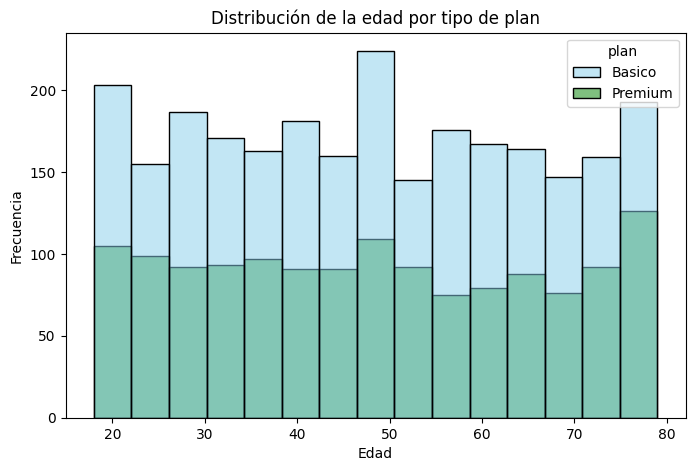

In [30]:



# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=15
)

plt.title("Distribución de la edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()




💡Insights: 
- Distribución ..
.La distribución de la edad es aproximadamente uniforme, ya que hay usuarios en casi todo el rango entre 20 y 80 años, sin una concentración muy marcada en un único intervalo.
-En el plan Básico se observa una mayor cantidad de usuarios en comparación con el plan Premium. Los picos de frecuencia se encuentran aproximadamente en las edades de 18, 50 y 79 años, con frecuencias cercanas a 200–230 usuarios.
- En el plan Premium la frecuencia de usuarios es considerablemente menor. Se aprecia un único pico importante alrededor de los 79 años, con una frecuencia aproximada de 140 usuarios.
- No se identifica un patrón claro que relacione la edad con el tipo de plan, aunque el plan Básico presenta una mayor representación de usuarios en prácticamente todos los rangos de edad.
- La distribución de la edad no parece ser claramente simétrica. Se observa una distribución relativamente uniforme con algunos picos de frecuencia, especialmente en el plan Básico

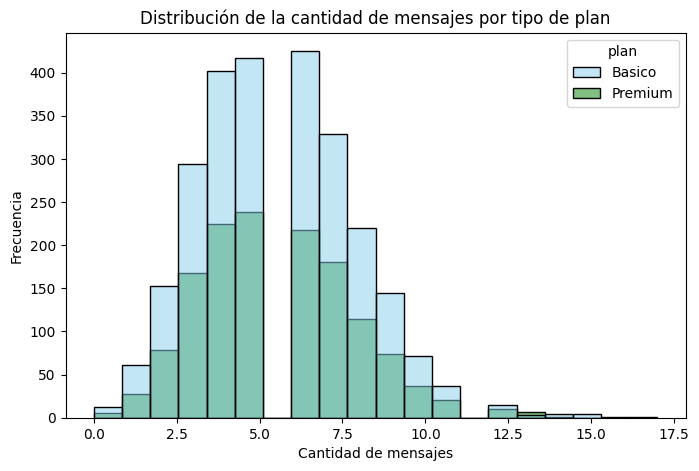

In [31]:



# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de la cantidad de mensajes por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")

plt.show()





💡Insights: 
- La cantidad de mensajes presenta una distribución sesgada a la derecha, ya que la mayoría de los usuarios envía entre 3 y 7 mensajes, mientras que solo unos pocos superan los 10 mensajes.
- Los usuarios del plan Básico registran una mayor frecuencia que los del plan Premium en prácticamente todos los niveles de uso, lo que indica que este plan concentra un mayor número de clientes.
- Tanto en el plan Básico como en el Premium se observa un comportamiento muy similar: la frecuencia aumenta gradualmente hasta alcanzar un pico entre 5 y 6 mensajes, y luego disminuye conforme aumenta la cantidad de mensajes enviados.
- Se identifican muy pocos usuarios con más de 12 mensajes, lo que sugiere la presencia de un pequeño grupo de usuarios con un uso intensivo del servicio, considerados posibles valores atípicos (outliers).
- No se observa un patrón que indique que un plan incentive un mayor envío de mensajes que el otro; la principal diferencia entre ambos es la cantidad de usuarios que posee cada plan, siendo el plan Básico el de mayor representación.

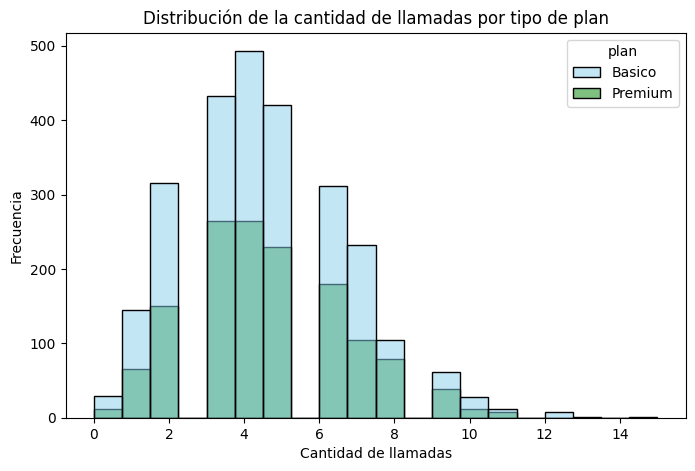

In [32]:





# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de la cantidad de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")

plt.show()







💡Insights: 
- La cantidad de llamadas presenta una distribución sesgada a la derecha, ya que la mayor parte de los usuarios realiza entre 3 y 6 llamadas, mientras que son pocos los que superan las 8 llamadas.
- Los usuarios del plan Básico presentan una mayor frecuencia en todos los niveles de uso respecto al plan Premium, lo que indica que este plan concentra un mayor número de clientes.
- En el plan Básico, la frecuencia aumenta progresivamente hasta alcanzar su máximo alrededor de 4 llamadas (cerca de 490 usuarios) y luego disminuye gradualmente a medida que aumenta la cantidad de llamadas.
- El plan Premium muestra un comportamiento similar, aunque con frecuencias menores. Su mayor concentración de usuarios también se encuentra entre 4 y 5 llamadas, disminuyendo progresivamente para cantidades superiores.
- Se observa que muy pocos usuarios realizan 9 o más llamadas, lo que sugiere la existencia de un pequeño grupo de usuarios con un uso intensivo del servicio, considerados posibles valores atípicos (outliers).
- No se evidencia una diferencia importante en el patrón de llamadas entre ambos planes; la principal diferencia radica en la cantidad de usuarios de cada plan, siendo el plan Básico el más representativo.

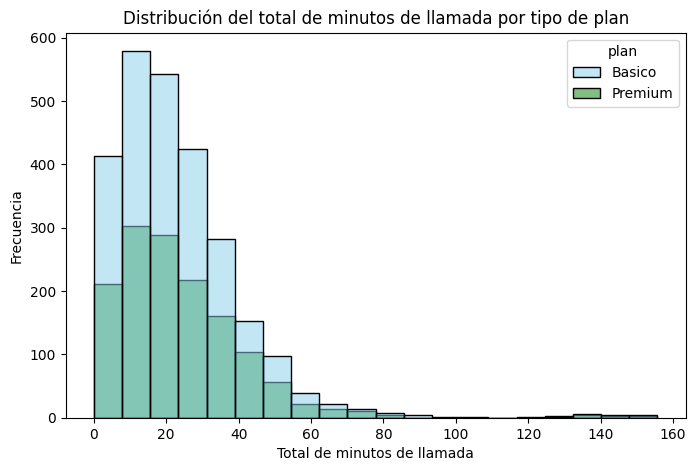

In [33]:


# Histograma para visualizar la cant_minutos_llamada


plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución del total de minutos de llamada por tipo de plan")
plt.xlabel("Total de minutos de llamada")
plt.ylabel("Frecuencia")

plt.show()






💡Insights: 
- La distribución del total de minutos de llamada está sesgada a la derecha, ya que la mayoría de los usuarios acumula entre 0 y 30 minutos de llamadas, mientras que son pocos los que superan los 60 minutos.
- En el plan Básico, la mayor concentración de usuarios se encuentra alrededor de los 10 minutos de llamadas, donde se registra la frecuencia más alta. A partir de este punto, la frecuencia disminuye progresivamente conforme aumenta el tiempo total de llamadas.
- El plan Premium presenta un comportamiento muy similar al del plan Básico, aunque con una menor cantidad de usuarios en todos los rangos de minutos.
- En ambos planes, la frecuencia de usuarios cae significativamente a partir de los 40 minutos, y para consumos superiores a 80 minutos la frecuencia es prácticamente nula.
- Se observa un pequeño grupo de usuarios con un consumo elevado de minutos (más de 60–80 minutos), lo que sugiere la presencia de posibles valores atípicos (outliers).
- No se identifican diferencias importantes en el patrón de consumo de minutos entre los planes Básico y Premium; la principal diferencia es que el plan Básico concentra un mayor número de usuarios,

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

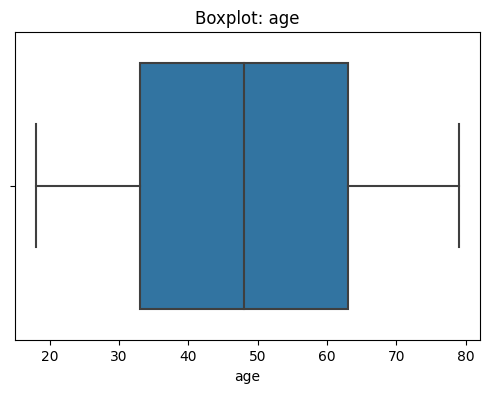

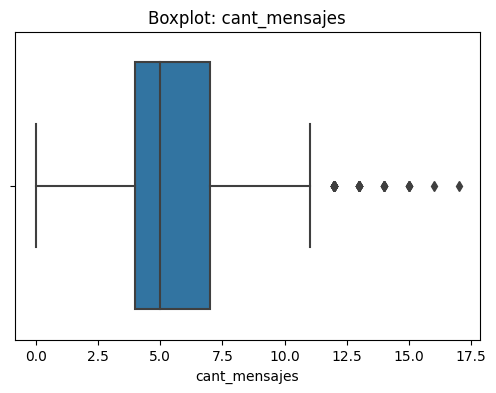

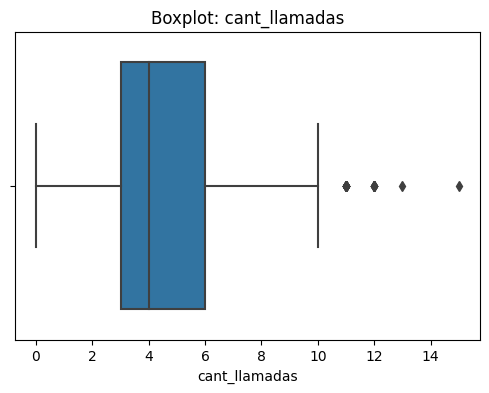

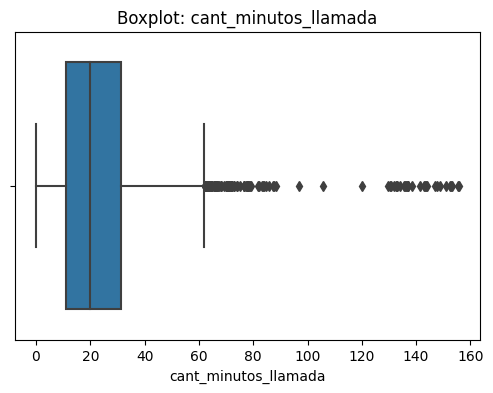

In [34]:


# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()




💡Insights: 
Age: No presenta outliers. Todas las edades se encuentran dentro de un rango esperado y no se observan puntos fuera de los límites del boxplot. Esto indica que la distribución de edades es consistente y no requiere tratamiento adicional.
cant_mensajes: Sí presenta outliers. Se observan algunos usuarios con 11 o más mensajes, valores que se encuentran por encima del límite superior del boxplot. Estos casos representan usuarios con un uso más intensivo del servicio de mensajería y, en principio, no deben eliminarse porque pueden corresponder a comportamientos reales.
cant_llamadas: Sí presenta outliers. Se identifican usuarios con 11 o más llamadas, ubicados por encima del límite superior. Estos valores reflejan clientes con una frecuencia de llamadas superior a la habitual y no necesariamente indican errores en los datos.
cant_minutos_llamada: Presenta una mayor cantidad de outliers que las demás variables. Se observan numerosos usuarios con más de 60 minutos de llamadas, alcanzando aproximadamente 150 minutos. Esto evidencia una distribución con cola larga hacia la derecha y un grupo de usuarios con consumo elevado de minutos. Estos registros representan un comportamiento válido de clientes intensivos, por lo que se recomienda conservarlos para el análisis y la segmentación, salvo que se detecten errores de captura.

In [35]:


# Calcular límites con el método IQR
# columnas_limites = [...]



# Variables que presentan outliers
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

# Calcular límites con el método IQR
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\nVariable: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite superior: {limite_superior:.2f}")







Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.50

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.50

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.86


In [35]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

cant_mensajes: Se mantienen los outliers, ya que corresponden a usuarios que envían una cantidad de mensajes superior al promedio. Estos valores representan un comportamiento real de clientes con un uso más intensivo del servicio y son útiles para identificar segmentos de alto consumo.
cant_llamadas: Se mantienen los outliers, porque reflejan usuarios que realizan un mayor número de llamadas que la mayoría. No se observan valores imposibles o inconsistentes, por lo que estos registros aportan información relevante para el análisis del comportamiento de los clientes.
cant_minutos_llamada: Se mantienen los outliers, debido a que representan clientes con un elevado consumo de minutos. Aunque el máximo (155.69 minutos) es considerablemente superior al valor típico, es un comportamiento plausible en un servicio de telecomunicaciones. Eliminar estos registros podría sesgar el análisis y dificultar la identificación de usuarios de alto consumo.

Conclusión general: Los outliers detectados en las tres variables corresponden a comportamientos reales del negocio y no a errores de captura o medición. Por ello, se decide conservarlos para el análisis, ya que aportan información valiosa para la segmentación de clientes y la toma de decisiones comerciales.







---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


In [ ]:
# verificar cambios
user_profile.head()

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [36]:


# Crear columna grupo_edad

user_profile["grupo_edad"] = "Adulto Mayor"

user_profile.loc[user_profile["age"] < 30, "grupo_edad"] = "Joven"
user_profile.loc[
    (user_profile["age"] >= 30) & (user_profile["age"] < 60),
    "grupo_edad"
] = "Adulto"

# Verificar el resultado
user_profile[["age", "grupo_edad"]].head()




,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [37]:


# verificar cambios
user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

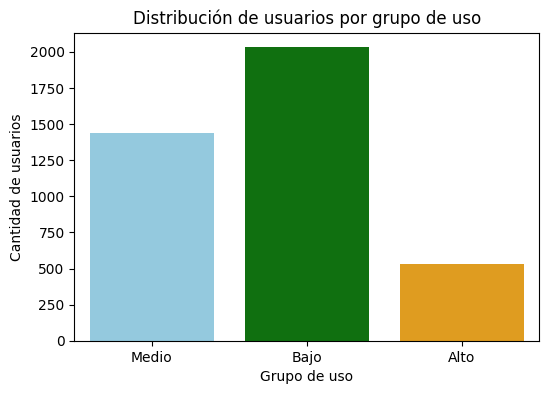

In [38]:



# Crear columna grupo_uso
user_profile["grupo_uso"] = "Alto"

user_profile.loc[user_profile["cant_minutos_llamada"] < 20, "grupo_uso"] = "Bajo"
user_profile.loc[
    (user_profile["cant_minutos_llamada"] >= 20) &
    (user_profile["cant_minutos_llamada"] < 40),
    "grupo_uso"
] = "Medio"

# Verificar cambios
user_profile[["cant_minutos_llamada", "grupo_uso"]].head()


# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()




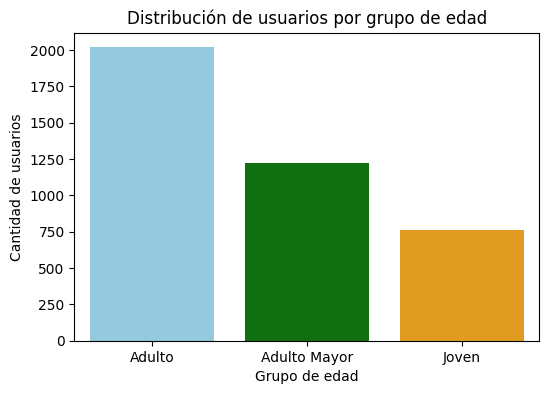

In [39]:


# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Durante la exploración y limpieza de los datos se identificaron los siguientes problemas:

Columna age: Existían valores sentinel (-999) que representaban edades inválidas. Estos fueron reemplazados por la mediana de la columna para mantener la distribución de los datos.
Columna city: Se encontraron registros con el valor "?", utilizado como sentinel para datos faltantes. Estos valores fueron reemplazados por NA.
Columna reg_date: Se detectaron fechas fuera del rango válido (fechas futuras), las cuales fueron marcadas como NA.
Columnas duration y length: Se verificó que los valores nulos eran MAR (Missing At Random), ya que dependían del tipo de registro (type). Por ejemplo, los mensajes no tienen duración y las llamadas no tienen longitud del mensaje, por lo que se decidió conservar estos valores nulos.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron dos tipos de segmentación:

Por edad:
Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto Mayor: 60 años o más.
Por nivel de uso: (según la clasificación realizada en el ejercicio).
Usuarios de bajo consumo.
Usuarios de consumo medio.
Usuarios de alto consumo.

En general, la mayor parte de los clientes pertenece al grupo Adulto, mientras que los usuarios de mayor consumo representan una proporción menor, pero generan un uso significativamente superior de los servicios.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los clientes de alto consumo son los más valiosos para ConnectaTel porque:

realizan más llamadas,
acumulan más minutos de conversación,
hacen un uso más intensivo de los servicios.

Este grupo representa una oportunidad para ofrecer planes Premium, beneficios exclusivos o programas de fidelización que ayuden a aumentar la retención y el ingreso promedio por cliente.



- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron outliers en:

Cantidad de mensajes.
Cantidad de llamadas.
Minutos de llamadas, siendo esta la variable con mayor cantidad de valores extremos.

Estos outliers corresponden a usuarios con un consumo muy superior al promedio. No representan errores en los datos, sino clientes con un comportamiento real de alto uso. Por ello, se decidió conservarlos, ya que aportan información importante para la segmentación y la toma de decisiones comerciales.

Se recomienda:

Diseñar planes diferenciados para usuarios de alto consumo, incluyendo mayores cantidades de minutos y beneficios adicionales.
Crear planes económicos dirigidos a usuarios de bajo consumo, evitando que paguen por servicios que no utilizan.
Implementar campañas de fidelización para los clientes con mayor consumo, ya que representan un segmento estratégico para la empresa.
Realizar campañas personalizadas según la edad y el comportamiento de uso para ofrecer productos más acordes con las necesidades de cada segmento.
Monitorear periódicamente los patrones de consumo para actualizar los planes comerciales y adaptarlos a los cambios en el comportamiento de los clientes.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

  

✍️ **Escribe aquí tu análisis ejecutivo:**

Conclusión ejecutiva

El análisis permitió mejorar la calidad de los datos mediante la corrección de valores inválidos y el tratamiento adecuado de los valores nulos. Asimismo, se identificaron segmentos de clientes según su edad y nivel de consumo, observándose que los usuarios de mayor uso constituyen un grupo estratégico para ConnectaTel. Los valores atípicos encontrados representan comportamientos reales de clientes intensivos y ofrecen una oportunidad para diseñar planes más personalizados, incrementar la fidelización y optimizar la rentabilidad de la empresa.



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se identificaron valores sentinel en la columna age (-999), los cuales fueron reemplazados por la mediana para preservar la distribución de las edades.
En la columna city se encontraron valores "?", que fueron reemplazados por valores nulos (NA).
Se detectaron fechas futuras en reg_date, las cuales fueron marcadas como valores nulos por ser inconsistentes.
Los valores nulos en duration y length se clasificaron como MAR (Missing At Random), ya que dependen del tipo de registro (call o text), por lo que se decidió mantenerlos.


🔍 **Segmentos por Edad**

Se clasificó a los clientes en tres grupos: Joven (menores de 30 años), Adulto (30 a 59 años) y Adulto Mayor (60 años o más).
El grupo Adulto concentra la mayor cantidad de usuarios, mientras que los grupos de Jóvenes y Adultos Mayores representan una menor proporción de la base de clientes.


📊 **Segmentos por Nivel de Uso**

Se identificaron usuarios con bajo, medio y alto nivel de consumo, diferenciándose por la cantidad de llamadas, mensajes y minutos utilizados.
También se detectaron usuarios con consumos muy superiores al promedio (outliers), especialmente en la variable cant_minutos_llamada, los cuales representan clientes de alto consumo y no errores en los datos.


➡️ Esto sugiere que ...

La mayor parte de los clientes presenta un consumo moderado de los servicios, mientras que un grupo reducido concentra un uso significativamente mayor.
Los usuarios de alto consumo representan una oportunidad para ofrecer planes Premium y estrategias de fidelización, mientras que los usuarios de bajo consumo podrían beneficiarse de planes más económicos y ajustados a sus necesidades.

💡 **Recomendaciones**

Diseñar planes diferenciados para clientes de alto consumo, incluyendo mayores beneficios en minutos y servicios adicionales.
Crear planes básicos para usuarios con bajo nivel de uso, con el fin de mejorar la satisfacción y reducir el riesgo de abandono.
Implementar campañas de fidelización dirigidas a los clientes de mayor consumo, ya que representan un segmento estratégico para ConnectaTel.
Continuar monitoreando los patrones de uso y actualizar periódicamente la segmentación para adaptar la oferta comercial a las necesidades reales de los clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`